In [1]:
!pip install mapboxgl
!pip install cartopy
!pip install contextily
!pip install rasterio
!pip install cartopy
!pip install mpltern

In [2]:
# Import Modules
import pandas as pd
from pandas import json_normalize
import geopandas as gpd
import numpy as np
from datetime import datetime
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

### Lagos

In [3]:
results_grid = gpd.read_file("model-output.gpkg")
results_grid.head()

,grid_id,longitude,latitude,lon_min,lat_min,lon_max,lat_max,Accessibility_standard,result,focused,geometry
0,136570,3.272601,6.590964,3.272099,6.590559,3.273104,6.591370,0.000087,2,0,"POLYGON ((3.2721 6.59137, 3.2731 6.59137, 3.27..."
1,136571,3.272598,6.590154,3.272095,6.589748,3.273100,6.590559,0.000086,2,0,"POLYGON ((3.2721 6.59056, 3.2731 6.59056, 3.27..."
2,136580,3.272568,6.582856,3.272066,6.582451,3.273071,6.583262,0.000093,2,0,"POLYGON ((3.27207 6.58326, 3.27307 6.58326, 3...."
3,137128,3.273606,6.591775,3.273104,6.591370,3.274109,6.592181,0.000108,2,0,"POLYGON ((3.27311 6.59218, 3.27411 6.59218, 3...."
4,137129,3.273603,6.590964,3.273100,6.590559,3.274106,6.591370,0.000105,2,0,"POLYGON ((3.2731 6.59137, 3.27411 6.59137, 3.2..."


In [4]:
# Load the validation dataset
validation_df = pd.read_csv('2026-01-27T09_11_45+00_00_0912.csv')
print(validation_df.shape)
validation_df.head()

(90301, 14)


,id,created_at,validation,user_id,user_background,user_map_usage,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
0,51c48ebe-f38f-4500-a80c-5ec1ac80bdca,2025-05-08T14:40:28.368385+00:00,1.0,a1c71b2b-d878-4e05-bae0-d4a1be92242b,['Just Browsing'],4.0,b37ec964-ce74-4c35-a465-12f8e97ff7bf,08a139b4-f2ef-4758-9969-860c7e889db0,Nairobi,Kenya,Accumulated Waste Piles,1,-1.286387,36.827204
1,0063f12d-3f04-47df-b7e0-3c55adbc09db,2025-05-22T12:36:28.908012+00:00,2.0,4466ebba-9700-4d0f-808d-a661cb693746,NaN,4.0,6e006408-ef2a-4b9c-bdac-15c737a14be7,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,2,11.996518,8.508990
2,934f028f-6e1b-4029-ab07-f41b269b204e,2025-05-22T12:41:19.334276+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,f80d0053-ede5-40fd-b2a6-dd1433d1eb1e,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.993255,8.472513
3,651d9931-6988-429b-940c-a2c46cd445bc,2025-05-22T12:41:28.409779+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,79d3eb25-b071-4613-9134-093cbb151e28,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.994071,8.471518
4,936c8a66-c7de-4d67-922b-1ba05ba05f39,2025-05-22T12:41:32.881643+00:00,1.0,15aa12bd-f20b-4a40-a1d8-5d57ae17eb1a,"['Just Browsing', 'Someone Different', 'gentle...",4.0,162a97eb-3e5b-466d-93ff-a9e080943927,6f38f125-0d6f-4b7f-9cb0-e3529e67da75,Kano,Nigeria,Morphological Informality,0,11.994071,8.470506


In [5]:
# Select pilot city
pilot = 'Lagos'  # Change this to the desired pilot city
# Load PAR data and filter by pilot city
par_expanded = validation_df[validation_df['output_model_city_name'] == f'{pilot.capitalize()}']

In [6]:
# Describe the shape of the validation data
print("Shape of PAR Data", par_expanded.shape)
par_expanded['output_model_subdomain_name'].value_counts()

Shape of PAR Data (36677, 14)


output_model_subdomain_name
Morphological Informality                      11449
Emergency Obstetric Care Access Deprivation     6174
Flood Hazard                                    6041
Road Access Deprivation                         5607
General Healthcare Access Deprivation           5312
Drinking Water Access Deprivation               2094
Name: count, dtype: int64

In [7]:
# Enter subdomain
subdomain = 'Drinking Water Access Deprivation'  # Change this to the desired subdomain

# Filter Data by Subdomain
par_subdomain = par_expanded[par_expanded['output_model_subdomain_name'] == subdomain]
par_subdomain.head()

,id,created_at,validation,user_id,user_background,user_map_usage,output_id,output_model,output_model_city_name,output_model_city_country,output_model_subdomain_name,output_result,output_latitude,output_longitude
86652,f4fd5884-4f0c-447a-a770-8ca60682588e,2026-01-19T13:36:39.843778+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,['Community Member'],2.0,c8684b02-8df0-42be-a3d7-a91e7cd6a703,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.607992,3.409929
86662,3f998ad6-98bf-46a5-ae11-43303efca13f,2026-01-19T13:37:50.664284+00:00,2.0,d6f1f42d-d5d2-4917-9d3c-3e521292bb2f,NaN,2.0,68d77f3f-8165-4845-8b5e-31b07cd12937,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.416929
86674,6bcdb870-a47e-4c6b-83a1-b2f052017006,2026-01-19T13:38:16.554319+00:00,1.0,b7085b3b-71ca-4479-bf70-4335856cf086,NaN,2.0,64f88ea1-79b8-473c-ae3b-129610a31e24,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.604748,3.415927
86675,78a7cec3-433d-496f-a73e-9552cdd22f41,2026-01-19T13:38:25.728696+00:00,2.0,dc0538f9-d2b3-4109-8116-b429cbebfecd,['Community Member'],2.0,15c6ba72-a907-4b96-992e-bb4000b482b6,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,1,6.605559,3.409919
86681,e484ee53-3376-44ea-ad72-8df989ee0585,2026-01-19T13:23:10.076725+00:00,1.0,b2559219-c7d6-47be-b589-0f58fda8686f,['Community Member'],2.0,9b8314af-f480-4997-a030-79bedeb29d66,9d7a6b72-cc1f-4e09-98bf-93a573671b96,Lagos,Nigeria,Drinking Water Access Deprivation,0,6.601505,3.427936


In [8]:
print(results_grid.shape)
print(results_grid.columns.tolist())
print('Accessibility_standard' in results_grid.columns)

if 'Accessibility_standard' in results_grid.columns:
    print(results_grid['Accessibility_standard'].describe())
    display(results_grid[['Accessibility_standard']].head())

(32247, 11)
['grid_id', 'longitude', 'latitude', 'lon_min', 'lat_min', 'lon_max', 'lat_max', 'Accessibility_standard', 'result', 'focused', 'geometry']
True
count    32247.000000
mean         0.003449
std          0.019723
min          0.000000
25%          0.000103
50%          0.000465
75%          0.001730
max          1.000000
Name: Accessibility_standard, dtype: float64


,Accessibility_standard
0,0.000087
1,0.000086
2,0.000093
3,0.000108
4,0.000105


In [9]:
val_majority = gpd.read_file ('par-majority-lagos-DW.gpkg')
val_majority

,output_latitude,output_longitude,val_count_0,val_count_1,val_count_2,model,val_total,val_max,val_vary,val_majority,geometry
0,6.604748,3.405908,0,1,0,1,1,1,0,1,"POLYGON ((3.40541 6.60515, 3.40641 6.60515, 3...."
1,6.607992,3.407926,0,0,2,1,2,2,0,2,"POLYGON ((3.40743 6.6084, 3.40843 6.6084, 3.40..."
2,6.607181,3.407922,0,2,4,1,6,4,1,2,"POLYGON ((3.40742 6.60759, 3.40842 6.60759, 3...."
3,6.606370,3.407919,0,2,1,1,3,2,1,1,"POLYGON ((3.40742 6.60678, 3.40842 6.60678, 3...."
4,6.604748,3.407912,1,0,0,1,1,1,0,0,"POLYGON ((3.40741 6.60515, 3.40841 6.60515, 3...."
...,...,...,...,...,...,...,...,...,...,...,...
418,6.605559,3.441979,0,0,1,1,1,1,0,2,"POLYGON ((3.44148 6.60596, 3.44248 6.60596, 3...."
419,6.611235,3.443006,0,1,0,1,1,1,0,1,"POLYGON ((3.44251 6.61164, 3.44351 6.61164, 3...."
420,6.608803,3.442995,0,0,1,1,1,1,0,2,"POLYGON ((3.4425 6.60921, 3.4435 6.60921, 3.44..."
421,6.607992,3.442992,0,0,1,1,1,1,0,2,"POLYGON ((3.44249 6.6084, 3.44349 6.6084, 3.44..."


In [10]:
# Make copies
results_grid2 = results_grid.copy()
val_majority2 = val_majority.copy()

# Round coordinates to consistent precision
results_grid2["lon_key"] = results_grid2["longitude"].round(6)
results_grid2["lat_key"] = results_grid2["latitude"].round(6)

val_majority2["lon_key"] = val_majority2["output_longitude"].round(6)
val_majority2["lat_key"] = val_majority2["output_latitude"].round(6)

# Merge on coordinate keys
Accessibility_index_val_majority = val_majority2.merge(
    results_grid2[["grid_id", "lon_key", "lat_key", "Accessibility_standard", "result", "focused"]],
    on=["lon_key", "lat_key"],
    how="left"
)

print("Joined rows:", len(Accessibility_index_val_majority))
print("Missing Accessibility_standard:", Accessibility_index_val_majority["Accessibility_standard"].isna().sum())

Accessibility_index_val_majority.head()

Joined rows: 423
Missing Accessibility_standard: 0


,output_latitude,output_longitude,val_count_0,val_count_1,val_count_2,model,val_total,val_max,val_vary,val_majority,geometry,lon_key,lat_key,grid_id,Accessibility_standard,result,focused
0,6.604748,3.405908,0,1,0,1,1,1,0,1,"POLYGON ((3.40541 6.60515, 3.40641 6.60515, 3....",3.405908,6.604748,203455,0.000514,1,1
1,6.607992,3.407926,0,0,2,1,2,2,0,2,"POLYGON ((3.40743 6.6084, 3.40843 6.6084, 3.40...",3.407926,6.607992,204582,0.000562,1,1
2,6.607181,3.407922,0,2,4,1,6,4,1,2,"POLYGON ((3.40742 6.60759, 3.40842 6.60759, 3....",3.407922,6.607181,204583,0.000572,1,1
3,6.606370,3.407919,0,2,1,1,3,2,1,1,"POLYGON ((3.40742 6.60678, 3.40842 6.60678, 3....",3.407919,6.606370,204584,0.000600,1,1
4,6.604748,3.407912,1,0,0,1,1,1,0,0,"POLYGON ((3.40741 6.60515, 3.40841 6.60515, 3....",3.407912,6.604748,204586,0.000535,1,1


In [16]:
lagos_calib = Accessibility_index_val_majority.copy()

print("Calibration cells:", len(lagos_calib))
display(lagos_calib[['val_majority', 'model', 'grid_id', 'Accessibility_standard', 'result']].head())

Calibration cells: 423


,val_majority,model,grid_id,Accessibility_standard,result
0,1,1,203455,0.000514,1
1,2,1,204582,0.000562,1
2,2,1,204583,0.000572,1
3,1,1,204584,0.000600,1
4,0,1,204586,0.000535,1


In [17]:
display(
    lagos_calib.groupby('val_majority')['Accessibility_standard'].describe()
)

display(
    lagos_calib.groupby('val_majority')['Accessibility_standard']
    .quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    .unstack()
)

,count,mean,std,min,25%,50%,75%,max
val_majority,,,,,,,,
0,56.0,0.010792,0.072517,0.000362,0.000702,0.001081,0.001566,0.543750
1,206.0,0.002377,0.005609,0.000158,0.000724,0.001313,0.001932,0.030390
2,161.0,0.000692,0.000391,0.000101,0.000475,0.000615,0.000785,0.002108


,0.10,0.25,0.50,0.75,0.90
val_majority,,,,,
0,0.000445,0.000702,0.001081,0.001566,0.002067
1,0.000504,0.000724,0.001313,0.001932,0.002102
2,0.000368,0.000475,0.000615,0.000785,0.000843


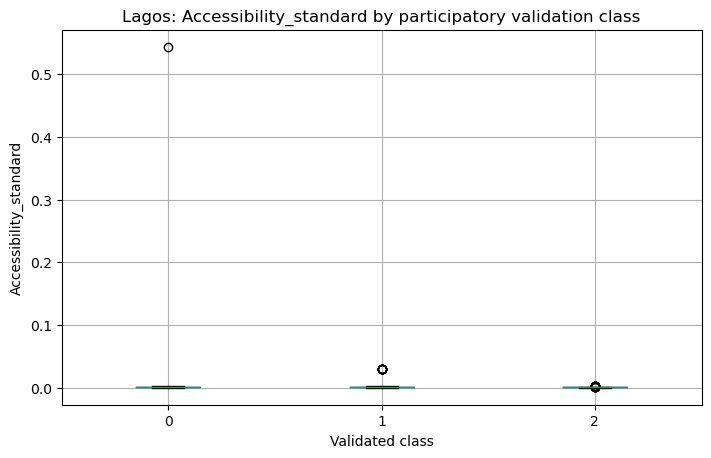

In [18]:
lagos_calib.boxplot(column='Accessibility_standard', by='val_majority', figsize=(8,5))
plt.title('Lagos: Accessibility_standard by participatory validation class')
plt.suptitle('')
plt.xlabel('Validated class')
plt.ylabel('Accessibility_standard')
plt.show()

In [19]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

df = kano_calib[['Accessibility_standard', 'val_majority', 'model']].copy()
df['Accessibility_standard'] = df['Accessibility_standard'].astype(float)
df['val_majority'] = df['val_majority'].astype(int)

# candidate thresholds from the observed distribution
candidates = np.unique(np.quantile(df['Accessibility_standard'], np.linspace(0.05, 0.95, 181)))

def classify_from_thresholds(x, t1, t2):
    if x <= t1:
        return 2   # High deprivation
    elif x <= t2:
        return 1   # Medium deprivation
    else:
        return 0   # Low deprivation

best = None
rows = []

for i, t1 in enumerate(candidates[:-1]):
    for t2 in candidates[i+1:]:
        y_pred = df['Accessibility_standard'].apply(lambda x: classify_from_thresholds(x, t1, t2))
        macro_f1 = f1_score(df['val_majority'], y_pred, average='macro')
        acc = accuracy_score(df['val_majority'], y_pred)
        rows.append((t1, t2, macro_f1, acc))
        
        if best is None or macro_f1 > best['macro_f1'] or (
            macro_f1 == best['macro_f1'] and acc > best['acc']
        ):
            best = {'t1': t1, 't2': t2, 'macro_f1': macro_f1, 'acc': acc}

search_results = pd.DataFrame(rows, columns=['t1', 't2', 'macro_f1', 'acc'])
search_results = search_results.sort_values(['macro_f1', 'acc'], ascending=False)

print("Best thresholds:")
print(best)

display(search_results.head(10))

Best thresholds:
{'t1': 0.0008459838930005538, 't2': 0.002074840534805958, 'macro_f1': 0.47453159256930766, 'acc': 0.5957446808510638}


,t1,t2,macro_f1,acc
11941,0.000846,0.002075,0.474532,0.595745
11937,0.000846,0.002057,0.474515,0.588652
12010,0.000884,0.002075,0.474172,0.595745
12006,0.000884,0.002057,0.474115,0.588652
11940,0.000846,0.002074,0.472970,0.593381
12009,0.000884,0.002074,0.472601,0.593381
11939,0.000846,0.002067,0.471139,0.591017
12008,0.000884,0.002067,0.470760,0.591017
11936,0.000846,0.002041,0.470757,0.583924
12005,0.000884,0.002041,0.470335,0.583924


In [20]:
t1 = best['t1']
t2 = best['t2']

lagos_calib['model_v2'] = lagos_calib['Accessibility_standard'].apply(
    lambda x: 2 if x <= t1 else (1 if x <= t2 else 0)
)

y_true = lagos_calib['val_majority'].astype(int)
y_pred_v1 = lagos_calib['model'].astype(int)
y_pred_v2 = lagos_calib['model_v2'].astype(int)

cm_v1 = confusion_matrix(y_true, y_pred_v1, labels=[0, 1, 2])
cm_v2 = confusion_matrix(y_true, y_pred_v2, labels=[0, 1, 2])

acc_v1 = accuracy_score(y_true, y_pred_v1)
acc_v2 = accuracy_score(y_true, y_pred_v2)

f1_v1 = f1_score(y_true, y_pred_v1, average='macro')
f1_v2 = f1_score(y_true, y_pred_v2, average='macro')

print("Lagos V1")
print(cm_v1)
print("Accuracy:", round(acc_v1, 3))
print("Macro F1:", round(f1_v1, 3))

print("\nLagos V2")
print(cm_v2)
print("Accuracy:", round(acc_v2, 3))
print("Macro F1:", round(f1_v2, 3))

print("\nClassification report for Lagos V2")
print(classification_report(
    y_true, y_pred_v2,
    labels=[0, 1, 2],
    target_names=['Low', 'Medium', 'High'],
    digits=3
))

Lagos V1
[[ 28  28   0]
 [111  94   1]
 [ 12 147   2]]
Accuracy: 0.293
Macro F1: 0.23

Lagos V2
[[  6  23  27]
 [ 29  99  78]
 [  3  11 147]]
Accuracy: 0.596
Macro F1: 0.475

Classification report for Lagos V2
              precision    recall  f1-score   support

         Low      0.158     0.107     0.128        56
      Medium      0.744     0.481     0.584       206
        High      0.583     0.913     0.712       161

    accuracy                          0.596       423
   macro avg      0.495     0.500     0.475       423
weighted avg      0.605     0.596     0.572       423

